# Yeni Bölüm

In [ ]:
X_test_sel.head(50).to_csv('sample_attacks.csv', index=False)

In [ ]:
import joblib

print("Packaging process is starting...")

# 1. Save the Trained Model (XGBoost)
joblib.dump(xgb_model, '/content/drive/MyDrive/nids_xgboost_model.pkl')
print("✅ Model packaged successfully.")

# 2. Save the Data Scaler
joblib.dump(scaler, '/content/drive/MyDrive/nids_scaler.pkl')
print("✅ Scaler packaged successfully.")

# 3. Save the List of the Top 20 Selected Features
joblib.dump(list(top_features), '/content/drive/MyDrive/nids_top_features.pkl')
print("✅ Feature list packaged successfully.")

print("\n🎉 All files have been successfully saved to the root directory of your Google Drive (MyDrive)!")

Packaging process is starting...
✅ Model packaged successfully.
✅ Scaler packaged successfully.
✅ Feature list packaged successfully.

🎉 All files have been successfully saved to the root directory of your Google Drive (MyDrive)!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import joblib
features = joblib.load('/content/drive/MyDrive/nids_top_features.pkl')
print(features)

['4', '5', '37', '33', '22', '29', '38', '3_SF', '32', '11', '35', '34', '28', '3_S0', '2_http', '25', '36', '39', '2_ecr_i', '24']


In [ ]:
!pip install imbalanced-learn -q

Mounted at /content/drive
1. NSL-KDD veri seti yükleniyor...
2. Saldırı türleri 5 kategoriye gruplanıyor...

Ham sınıf dağılımı:
41
NORMAL    67343
DOS       45927
PROBE     11656
R2L         995
U2R          52
Name: count, dtype: int64

Class mapping: {'DOS': 0, 'NORMAL': 1, 'PROBE': 2, 'R2L': 3, 'U2R': 4}
3. MinMax scaling (sadece train üzerinde fit)...
   Scale edilecek 38 numeric kolon var.
4. Feature selection — Top 20 (class_weight='balanced')...
   Seçilen 20 feature: ['4', '32', '5', '34', '11', '37', '2_http', '23', '35', '22', '0', '33', '31', '9', '2_ftp_data', '29', '36', '3_S0', '24', '25']

5. SMOTE uygulanıyor (azınlık sınıflar oversampling)...
   Öncesi: {0: 36741, 1: 53874, 2: 9325, 3: 796, 4: 42}
   En küçük sınıf: 42 örnek, k_neighbors=5
   Sonrası: {0: 53874, 1: 53874, 2: 53874, 3: 53874, 4: 53874}

6. XGBoost eğitiliyor (Maliyet Duyarlı Öğrenme)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:07:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "sample_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



7. Test set üzerinde değerlendirme...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         DOS     0.9997    0.9997    0.9997      9186
      NORMAL     0.9990    0.9988    0.9989     13469
       PROBE     0.9970    0.9961    0.9966      2331
         R2L     0.9801    0.9899    0.9850       199
         U2R     0.7500    0.9000    0.8182        10

    accuracy                         0.9988     25195
   macro avg     0.9451    0.9769    0.9597     25195
weighted avg     0.9988    0.9988    0.9988     25195



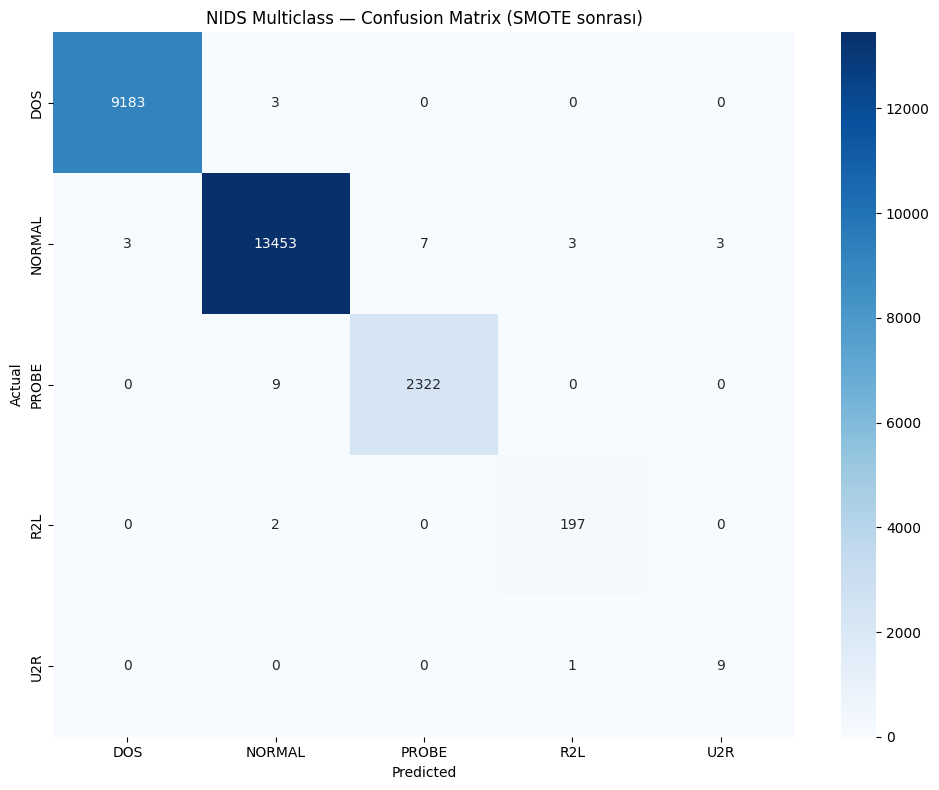

/tmp/ipykernel_1784/1437643111.py:180: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette='viridis')


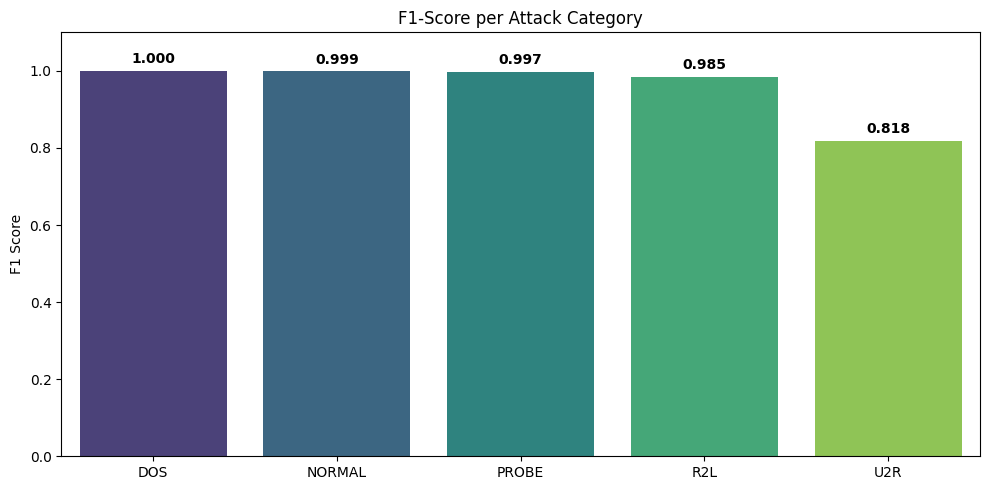


8. Asset'ler kaydediliyor...

✅ Tüm asset'ler kaydedildi:
   - nids_model_v2.pkl         → XGBoost modeli
   - nids_scaler_v2.pkl        → MinMax scaler (sadece numeric_cols için fit)
   - nids_top_features.pkl     → Modelin beklediği 20 feature
   - nids_numeric_cols.pkl     → Scale edilecek orijinal sayısal kolonlar
   - nids_all_columns.pkl      → One-hot sonrası TÜM kolonlar (backend için)
   - nids_class_mapping.pkl    → Etiket → sayı
   - nids_inverse_mapping.pkl  → Sayı → etiket (predict çıktısı için)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import joblib

# =============================================================================
# STEP 1: DATA LOADING
# =============================================================================
print("1. NSL-KDD veri seti yükleniyor...")
df = pd.read_csv('/content/drive/MyDrive/KDDTrain+.txt', header=None)

# NSL-KDD'de 43 kolon var: 0-40 features, 41 attack label, 42 difficulty
# Attack mapping (5 ana kategori)
attack_map = {
    'normal': 'NORMAL',
    # DoS
    'apache2': 'DOS', 'back': 'DOS', 'land': 'DOS', 'neptune': 'DOS',
    'mailbomb': 'DOS', 'pod': 'DOS', 'processtable': 'DOS', 'smurf': 'DOS',
    'teardrop': 'DOS', 'udpstorm': 'DOS', 'worm': 'DOS',
    # Probe
    'ipsweep': 'PROBE', 'mscan': 'PROBE', 'nmap': 'PROBE',
    'portsweep': 'PROBE', 'saint': 'PROBE', 'satan': 'PROBE',
    # R2L
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'httptunnel': 'R2L',
    'imap': 'R2L', 'multihop': 'R2L', 'named': 'R2L', 'phf': 'R2L',
    'sendmail': 'R2L', 'snmpgetattack': 'R2L', 'snmpguess': 'R2L',
    'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L',
    'xlock': 'R2L', 'xsnoop': 'R2L',
    # U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
    'ps': 'U2R', 'rootkit': 'U2R', 'sqlattack': 'U2R', 'xterm': 'U2R'
}

print("2. Saldırı türleri 5 kategoriye gruplanıyor...")
df[41] = df[41].map(attack_map)

# Eğer attack_map'te olmayan bir tür varsa (NaN) kontrolü
if df[41].isna().any():
    print(f"UYARI: {df[41].isna().sum()} adet etiketlenmemiş satır var, bunlar atılıyor.")
    df = df.dropna(subset=[41])

print("\nHam sınıf dağılımı:")
print(df[41].value_counts())
print()

# One-hot encoding (kolon 1=protocol_type, 2=service, 3=flag)
df_clean = pd.get_dummies(df, columns=[1, 2, 3], drop_first=True)

# =============================================================================
# STEP 2: TRAIN / TEST SPLIT (SCALING'DEN ÖNCE!)
# =============================================================================
y = df_clean[41]
X = df_clean.drop(columns=[41, 42])  # 41=label, 42=difficulty
X.columns = X.columns.astype(str)

# Deterministik class mapping (sorted ile her run'da aynı sıra)
unique_labels = sorted(y.unique())
class_mapping = {label: i for i, label in enumerate(unique_labels)}
inverse_mapping = {v: k for k, v in class_mapping.items()}
y_encoded = y.map(class_mapping)

print(f"Class mapping: {class_mapping}")

# Stratified split — azınlık sınıflarının test'te de bulunmasını garanti eder
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# =============================================================================
# STEP 3: SCALING (SADECE TRAIN ÜZERİNDE FIT — DATA LEAKAGE FIX)
# =============================================================================
print("3. MinMax scaling (sadece train üzerinde fit)...")

# One-hot kolonları zaten 0/1 olduğu için sadece orijinal sayısal feature'ları scale et
# get_dummies bool/uint8 üretir; orijinal sayısal feature'lar int64/float64'tür
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"   Scale edilecek {len(numeric_cols)} numeric kolon var.")

scaler = MinMaxScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])  # SADECE transform!

# =============================================================================
# STEP 4: FEATURE SELECTION (class_weight='balanced' İLE)
# =============================================================================
print("4. Feature selection — Top 20 (class_weight='balanced')...")
rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Azınlık sınıflarına ağırlık verir
)
rf_selector.fit(X_train, y_train)

feature_importances = pd.Series(
    rf_selector.feature_importances_, index=X_train.columns
).sort_values(ascending=False)
top_features = feature_importances.head(20).index.tolist()
print(f"   Seçilen 20 feature: {top_features}")

X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]

# =============================================================================
# STEP 5: SMOTE — SINIF DENGELEME (R2L/U2R İÇİN KRİTİK)
# =============================================================================
print("\n5. SMOTE uygulanıyor (azınlık sınıflar oversampling)...")
print(f"   Öncesi: {pd.Series(y_train).value_counts().sort_index().to_dict()}")

# k_neighbors en küçük sınıf boyutundan az olmalı; güvenlik için min al
min_class_count = pd.Series(y_train).value_counts().min()
k_neighbors = min(5, max(1, min_class_count - 1))
print(f"   En küçük sınıf: {min_class_count} örnek, k_neighbors={k_neighbors}")

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_balanced, y_balanced = smote.fit_resample(X_train_sel, y_train)
print(f"   Sonrası: {pd.Series(y_balanced).value_counts().sort_index().to_dict()}")

# --- STEP 6: XGBOOST EĞİTİMİ (R2L ve U2R KURTARMA OPERASYONU) ---
print("\n6. XGBoost eğitiliyor (Maliyet Duyarlı Öğrenme)...")

# Her satır için varsayılan ağırlık 1
weights = np.ones(len(y_balanced))

# R2L (3) ve U2R (4) sınıfları hata yaparsa modele 50 KAT ceza ver!
weights[y_balanced == 3] = 50.0
weights[y_balanced == 4] = 60.0

xgb_model = xgb.XGBClassifier(
    n_estimators=300, # Daha fazla ağaç
    max_depth=10,     # Daha derin analiz
    learning_rate=0.05,
    objective='multi:softmax',
    num_class=len(class_mapping),
    random_state=42,
    sample_weight=weights # İŞTE KRİTİK NOKTA!
)

xgb_model.fit(X_balanced, y_balanced)
# Modeli ve diğer dosyaları tekrar kaydetmeyi unutmasın!

# =============================================================================
# STEP 7: DEĞERLENDİRME
# =============================================================================
print("\n7. Test set üzerinde değerlendirme...")
preds = xgb_model.predict(X_test_sel)
target_names = [inverse_mapping[i] for i in sorted(inverse_mapping.keys())]

print("\n" + "=" * 65)
print("CLASSIFICATION REPORT")
print("=" * 65)
print(classification_report(y_test, preds, target_names=target_names, digits=4))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('NIDS Multiclass — Confusion Matrix (SMOTE sonrası)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# F1 bar chart — sınıf bazlı performansı net görmek için
report_dict = classification_report(
    y_test, preds, target_names=target_names, output_dict=True
)
f1_scores = {key: report_dict[key]['f1-score'] for key in target_names}
plt.figure(figsize=(10, 5))
sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette='viridis')
plt.title('F1-Score per Attack Category')
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
for i, v in enumerate(f1_scores.values()):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================================================
# STEP 8: ASSET'LERİ KAYDET
# =============================================================================
print("\n8. Asset'ler kaydediliyor...")

joblib.dump(xgb_model, 'nids_model_v2.pkl')
joblib.dump(top_features, 'nids_top_features.pkl')
joblib.dump(scaler, 'nids_scaler_v2.pkl')               # DOĞRU scaler!
joblib.dump(numeric_cols, 'nids_numeric_cols.pkl')      # Hangi kolonların scale edileceği
joblib.dump(class_mapping, 'nids_class_mapping.pkl')
joblib.dump(inverse_mapping, 'nids_inverse_mapping.pkl')
joblib.dump(X_train.columns.tolist(), 'nids_all_columns.pkl')  # Backend feature alignment için

print("\n✅ Tüm asset'ler kaydedildi:")
print("   - nids_model_v2.pkl         → XGBoost modeli")
print("   - nids_scaler_v2.pkl        → MinMax scaler (sadece numeric_cols için fit)")
print("   - nids_top_features.pkl     → Modelin beklediği 20 feature")
print("   - nids_numeric_cols.pkl     → Scale edilecek orijinal sayısal kolonlar")
print("   - nids_all_columns.pkl      → One-hot sonrası TÜM kolonlar (backend için)")
print("   - nids_class_mapping.pkl    → Etiket → sayı")
print("   - nids_inverse_mapping.pkl  → Sayı → etiket (predict çıktısı için)")

In [ ]:
# Test setinden gerçek R2L örneklerini bul
r2l_idx = y_test[y_test == class_mapping['R2L']].index[:3]
print("Gerçek R2L örnekleri (top_features):")
print(X_test_sel.loc[r2l_idx])
print("\nModel ne diyor?")
print([inverse_mapping[p] for p in xgb_model.predict(X_test_sel.loc[r2l_idx])])

Gerçek R2L örnekleri (top_features):
                   4        32         5    34   11    37  2_http        23  \
63689   2.420353e-07  0.125490  0.000000  0.00  1.0  0.00   False  0.003914   
112769  9.174153e-07  0.086275  0.000002  0.05  1.0  0.02   False  0.001957   
17248   2.420353e-07  0.184314  0.000000  0.00  1.0  0.00   False  0.003914   

          35        22         0    33        31         9  2_ftp_data   29  \
63689   1.00  0.003914  0.000000  1.00  0.007843  0.000000        True  0.0   
112769  0.01  0.001957  0.000023  0.18  0.486275  0.363636       False  0.0   
17248   1.00  0.003914  0.000000  1.00  0.023529  0.000000        True  0.0   

          36   3_S0   24   25  
63689   0.19  False  0.0  0.0  
112769  0.00  False  0.0  0.0  
17248   0.13  False  0.0  0.0  

Model ne diyor?
['R2L', 'R2L', 'R2L']


In [ ]:
import json
import numpy as np

print("// === REACT FRONTEND İÇİN GERÇEK PAYLOADLAR ===\n")

# Tüm 5 sınıf için birer tane GERÇEK test verisi çekelim
for class_name, class_id in class_mapping.items():
    # Bu sınıfa ait test verilerinin indekslerini bul
    idx = y_test[y_test == class_id].index
    if len(idx) == 0:
        continue

    # Sınıfa ait ilk örneği al
    sample = X_test_sel.loc[idx[0]]

    # Değerleri React'in anlayacağı formata (0-1 arası) çevir
    payload = {}
    for col, val in sample.items():
        if isinstance(val, (bool, np.bool_)):
            payload[col] = 1.0 if val else 0.0
        else:
            payload[col] = round(float(val), 6)

    # Ekrana kopyalanabilir şekilde yazdır
    js_obj = ", ".join([f'"{k}": {v}' for k, v in payload.items()])
    print(f"// {class_name}")
    print(f"payload_{class_name} = {{ {js_obj} }};\n")

// === REACT FRONTEND İÇİN GERÇEK PAYLOADLAR ===

// DOS
payload_DOS = { "4": 0.0, "32": 0.098039, "5": 0.0, "34": 0.05, "11": 0.0, "37": 1.0, "2_http": 0.0, "23": 0.048924, "35": 0.0, "22": 0.587084, "0": 0.0, "33": 0.1, "31": 1.0, "9": 0.0, "2_ftp_data": 0.0, "29": 0.05, "36": 0.0, "3_S0": 1.0, "24": 1.0, "25": 1.0 };

// NORMAL
payload_NORMAL = { "4": 0.0, "32": 0.996078, "5": 0.0, "34": 0.0, "11": 0.0, "37": 0.0, "2_http": 1.0, "23": 0.001957, "35": 0.02, "22": 0.001957, "0": 0.0, "33": 1.0, "31": 0.172549, "9": 0.0, "2_ftp_data": 0.0, "29": 0.0, "36": 0.18, "3_S0": 0.0, "24": 0.0, "25": 0.0 };

// PROBE
payload_PROBE = { "4": 0.0, "32": 0.003922, "5": 0.0, "34": 1.0, "11": 0.0, "37": 0.04, "2_http": 0.0, "23": 0.001957, "35": 0.0, "22": 0.962818, "0": 0.0, "33": 0.0, "31": 1.0, "9": 0.0, "2_ftp_data": 0.0, "29": 1.0, "36": 0.0, "3_S0": 0.0, "24": 0.07, "25": 0.0 };

// R2L
payload_R2L = { "4": 0.0, "32": 0.12549, "5": 0.0, "34": 0.0, "11": 1.0, "37": 0.0, "2_http": 0.0, "23": 0.00